# 05 — Optimisation, champion/challenger et évaluation externe NASA

Le holdout NASA est ouvert **seulement après** la fin de la sélection, de l'optimisation, du choix du seuil et de la promotion du champion.


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve,
)


In [2]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

print("Project root :", ROOT)
print("Raw data     :", DATA_RAW)


Project root : C:\Users\Admin\Desktop\predictmaint-ai
Raw data     : C:\Users\Admin\Desktop\predictmaint-ai\data\raw


### Analyse du résultat

Le notebook lit les artefacts figés dans `models` et n'ouvre le holdout NASA qu'après la décision de promotion, ce qui préserve son rôle d'évaluation externe.


## 1. Rapport d’optimisation Optuna — TRAIN groupé uniquement


In [3]:
optimization = json.loads((MODELS_DIR / "optimization_report.json").read_text(encoding="utf-8"))
print("Best params :")
print(json.dumps(optimization["best_params"], indent=2))
print()
print("Métriques de validation du challenger :")
display(pd.DataFrame([optimization["validation_metrics"]]))


Best params :
{
  "n_estimators": 273,
  "max_depth": 3,
  "learning_rate": 0.1648515081300764,
  "subsample": 0.9212964881763901,
  "colsample_bytree": 0.9788246295474662,
  "min_child_weight": 9.053446153848839,
  "reg_alpha": 0.04751937318279559,
  "reg_lambda": 4.869640941520899
}

Métriques de validation du challenger :


,threshold,precision,recall,specificity,balanced_accuracy,f1,mcc,roc_auc,pr_auc,brier,tn,fp,fn,tp,business_cost,business_cost_per_1000
0,0.002845,0.563636,1.0,0.861485,0.930743,0.72093,0.696824,0.988134,0.945949,0.031164,2239,360,0,465,180000.0,58746.736292


### Analyse du résultat

Le challenger optimisé atteint 100 % de rappel sur validation verrouillée, avec 360 faux positifs et aucun faux négatif. Son coût de 180 000 est inférieur à celui du champion précédent, même si sa précision (56,4 %), sa PR-AUC et son score de Brier sont moins bons.


## 2. Décision champion/challenger


In [4]:
promotion = json.loads((MODELS_DIR / "promotion_report.json").read_text(encoding="utf-8"))
print(json.dumps(promotion, indent=2))


{
  "promoted": true,
  "guardrails_ok": true,
  "candidate_better_on_locked_validation": true,
  "champion": {
    "name": "random_forest",
    "validation_metrics": {
      "name": "random_forest",
      "threshold_source": "dedicated calibration engines",
      "calibration_pr_auc": 0.9598626053618143,
      "calibration_recall": 0.9913978494623656,
      "threshold": 0.13,
      "precision": 0.6579710144927536,
      "recall": 0.9763440860215054,
      "specificity": 0.9091958445555983,
      "balanced_accuracy": 0.9427699652885518,
      "f1": 0.7861471861471861,
      "mcc": 0.760628970486397,
      "roc_auc": 0.9889593598861431,
      "pr_auc": 0.9494418594143065,
      "brier": 0.028183800483526564,
      "tn": 2363,
      "fp": 236,
      "fn": 11,
      "tp": 454,
      "business_cost": 228000.0,
      "business_cost_per_1000": 74412.53263707571
    }
  },
  "candidate": {
    "name": "xgboost_optimized",
    "validation_metrics": {
      "threshold": 0.002844517994672067,
  

### Analyse du résultat

La promotion est cohérente avec la règle annoncée : les guardrails passent, puis le coût métier prime (180 000 contre 228 000). Le gain économique provient de l'élimination des 11 faux négatifs, au prix de 124 fausses alertes supplémentaires ; ce compromis doit être assumé opérationnellement.


## 3. Ouverture explicite du holdout externe

Ici seulement, on charge `test_FD001.txt` et `RUL_FD001.txt` pour l'évaluation finale.


In [5]:
columns = [
    "engine_id", "cycle", "setting_1", "setting_2", "setting_3",
    *[f"sensor_{i}" for i in range(1, 22)],
]

test = pd.read_csv(
    DATA_RAW / "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns,
)

rul_last = pd.read_csv(
    DATA_RAW / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL_at_last_observation"],
)

print("Test NASA :", test.shape)
print("RUL       :", rul_last.shape)
assert len(rul_last) == test.engine_id.nunique()


Test NASA : (13096, 26)
RUL       : (100, 1)


### Analyse du résultat

Le holdout contient 13 096 cycles pour 100 moteurs et exactement 100 valeurs de RUL terminal. Les cardinalités permettent un rattachement univoque, qui est vérifié à l'étape suivante.


## 4. Reconstruction manuelle du RUL vrai du test


In [6]:
max_observed = test.groupby("engine_id")["cycle"].max().rename("max_observed_cycle")

mapping = pd.DataFrame({
    "engine_id": sorted(test["engine_id"].unique()),
    "RUL_at_last_observation": rul_last["RUL_at_last_observation"].to_numpy(),
})

test_labelled = (
    test.merge(max_observed, on="engine_id", how="left")
        .merge(mapping, on="engine_id", how="left")
)

test_labelled["RUL"] = (
    test_labelled["max_observed_cycle"]
    - test_labelled["cycle"]
    + test_labelled["RUL_at_last_observation"]
)

test_labelled["failure_within_30_cycles"] = (
    test_labelled["RUL"] <= 30
).astype("int8")

display(test_labelled[[
    "engine_id", "cycle", "max_observed_cycle",
    "RUL_at_last_observation", "RUL", "failure_within_30_cycles"
]].head(10))


,engine_id,cycle,max_observed_cycle,RUL_at_last_observation,RUL,failure_within_30_cycles
0,1,1,31,112,142,0
1,1,2,31,112,141,0
2,1,3,31,112,140,0
3,1,4,31,112,139,0
4,1,5,31,112,138,0
5,1,6,31,112,137,0
6,1,7,31,112,136,0
7,1,8,31,112,135,0
8,1,9,31,112,134,0
9,1,10,31,112,133,0


### Analyse du résultat

Le RUL de chaque ligne est reconstruit comme le nombre de cycles restants après le dernier cycle observé, plus la distance jusqu'à celui-ci. Pour le moteur 1, le cycle 1 a ainsi un RUL de 142 et la cible reste négative, ce qui valide le sens du calcul.


## 5. Feature engineering causal + modèle champion

Le champion sérialisé est chargé avec `joblib`. Sa compatibilité n'est pas garantie entre versions différentes de Python, scikit-learn ou XGBoost : les versions d'entraînement sont enregistrées dans `model_metadata.json` et doivent être comparées à l'environnement courant. En cas d'avertissement de version, il faut recréer l'environnement d'origine ou réentraîner et revalider l'artefact avant d'interpréter l'évaluation. Cette contrainte de reproductibilité est indépendante des contrôles anti-fuite.


In [7]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.build_features import build_causal_features

metadata = json.loads((MODELS_DIR / "model_metadata.json").read_text(encoding="utf-8"))
selected = json.loads((MODELS_DIR / "selected_features.json").read_text(encoding="utf-8"))
model = joblib.load(MODELS_DIR / "model.joblib")
threshold = float(metadata["threshold"])

test_features = build_causal_features(test_labelled)
X_test = test_features[selected]
y_test = test_features["failure_within_30_cycles"].astype(int)

probability = model.predict_proba(X_test)[:, 1]
prediction = (probability >= threshold).astype(int)


C:\Users\Admin\Desktop\predictmaint-ai\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\pickle.py:1718: UserWarning: [12:26:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.



### Analyse du résultat

Le modèle s'exécute, mais les avertissements signalent qu'il a été sérialisé avec scikit-learn 1.8 puis chargé avec 1.9, ainsi qu'avec une autre version de XGBoost. Les métriques sont reproductibles ici, mais l'artefact doit être réexporté dans l'environnement de production avant déploiement pour supprimer ce risque de compatibilité.


## 6. Métriques externes finales


In [8]:
metrics = {
    "precision": precision_score(y_test, prediction, zero_division=0),
    "recall": recall_score(y_test, prediction, zero_division=0),
    "f1": f1_score(y_test, prediction, zero_division=0),
    "pr_auc": average_precision_score(y_test, probability),
    "roc_auc": roc_auc_score(y_test, probability),
}

display(pd.DataFrame([metrics]))


,precision,recall,f1,pr_auc,roc_auc
0,0.321138,0.951807,0.480243,0.76748,0.989503


### Analyse du résultat

Sur le holdout externe, le rappel reste élevé (95,2 %) et la ROC-AUC atteint 0,990, mais la précision tombe à 32,1 % et la PR-AUC à 0,767. Le modèle détecte donc presque toutes les périodes à risque, au prix d'un volume important de fausses alertes ; cet écart avec validation indique un transfert de distribution imparfait.


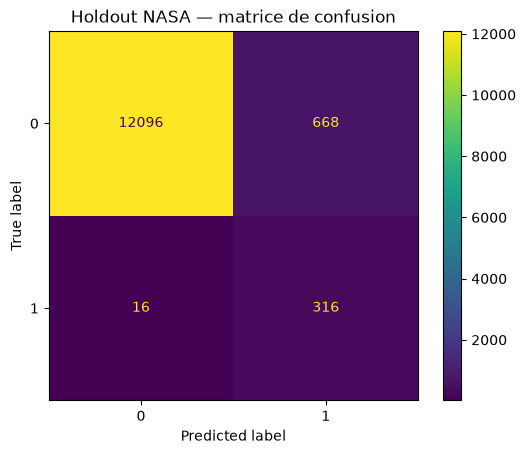

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, prediction)
plt.title("Holdout NASA — matrice de confusion")
plt.show()

### Analyse du résultat

La matrice de confusion isole le compromis au seuil déployé : 316 vrais positifs et 16 faux négatifs, contre 668 faux positifs. Le rappel élevé est obtenu avec environ deux fausses alertes pour chaque vraie alerte.


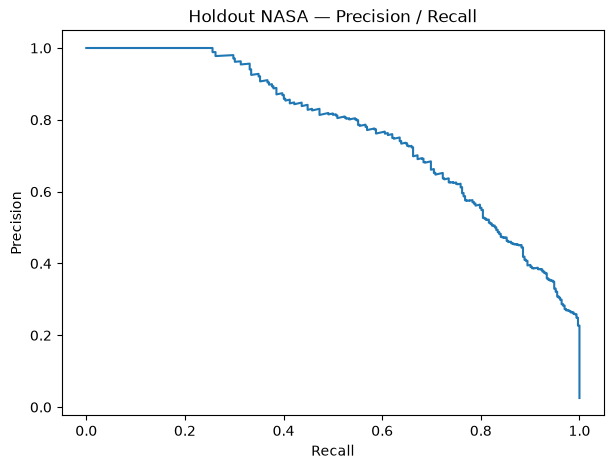

In [10]:
precision, recall, _ = precision_recall_curve(y_test, probability)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Holdout NASA — Precision / Recall")
plt.show()


### Analyse du résultat

La courbe précision–rappel est affichée dans une figure séparée pour éviter une grille de graphiques. Elle montre les seuils possibles ; le point déployé privilégie la couverture des pannes plutôt que la précision des alertes.


## 7. Vérification avec l'artefact officiel du pipeline

Le fichier `models/test_metrics.json` est produit par `python -m src.models.evaluate`. On compare les résultats du notebook à ceux du pipeline pour vérifier la reproductibilité.


In [11]:
reported = json.loads((MODELS_DIR / "test_metrics.json").read_text(encoding="utf-8"))
print(json.dumps(reported, indent=2))


{
  "threshold": 0.002844517994672067,
  "precision": 0.32113821138211385,
  "recall": 0.9518072289156626,
  "specificity": 0.9476653086806643,
  "balanced_accuracy": 0.9497362687981634,
  "f1": 0.48024316109422494,
  "mcc": 0.5363457794410529,
  "roc_auc": 0.9895026675174532,
  "pr_auc": 0.7674797246109482,
  "brier": 0.012266476569588371,
  "tn": 12096,
  "fp": 668,
  "fn": 16,
  "tp": 316,
  "business_cost": 494000.0,
  "business_cost_per_1000": 37721.44166157605,
  "evaluated_at_utc": "2026-08-27T12:15:39.930785+00:00",
  "model_name": "xgboost_optimized",
  "model_version": "optimized-b623fc94786a",
  "dataset": "NASA C-MAPSS FD001 external holdout",
  "locked_external_holdout": true,
  "holdout_loaded_only_at_evaluation": true,
  "raw_test_quality": {
    "rows": 13096,
    "columns": 26,
    "engines": 100,
    "missing_columns": [],
    "extra_columns": [],
    "duplicated_engine_cycle_keys": 0,
    "total_null_values": 0,
    "non_finite_numeric_values": 0,
    "non_monotonic_

### Analyse du résultat

Les métriques recalculées concordent avec l'artefact officiel : 12 096 TN, 668 FP, 16 FN et 316 TP, pour un coût de 494 000 (37 721 par 1 000 observations). Ces résultats doivent rester un constat final et ne pas alimenter une nouvelle boucle de tuning sur ce holdout.


## Conclusion

L'écart éventuel entre validation et holdout NASA est documenté, pas masqué. Le holdout externe reste hors de la boucle automatique de tuning et de retraining.
